<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**

En el dominio del tiempo podemos analizar como se comporta la señal a lo largo del tiempo, mientras que en el dominio de la frecuencia se analiza qué componentes de frecuencia están presentes y cuál es su importancia en la señal.


In [ ]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 0
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 0


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [ ]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [ ]:
# ============================================
# CARGAR LOS TRES REGISTROS
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")


Registro 16265 cargado correctamente.
Registro 16272 cargado correctamente.
Registro 16420 cargado correctamente.


In [ ]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 45
Anotaciones del registro 16272: 31
Anotaciones del registro 16420: 44


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [ ]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo de cada registro?
   
   Registro 16265: 128 Hz, Registro 16272: 128 Hz, Registro 16420: 128 Hz
2. ¿Los tres registros tienen la misma frecuencia de muestreo?

   Si
3. ¿Cuántos canales posee cada registro?
   
   Todos los registros tienen 2 canales
4. ¿Qué señal corresponde al canal `0`?

   A la señal ECG1
5. ¿Cuántas muestras contiene cada registro?

   Todos los registros contienen 3600 muestras
6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`?

   La frecuencia de muestreo es la cantidad de muestras que se toman por segundo, para hallar el tiempo realizamos el cálculo #muestras/fs = 3600/360 = 10 s


# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [ ]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG1
16272: 3600 muestras, fs = 128 Hz, canal = ECG1
16420: 3600 muestras, fs = 128 Hz, canal = ECG1


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


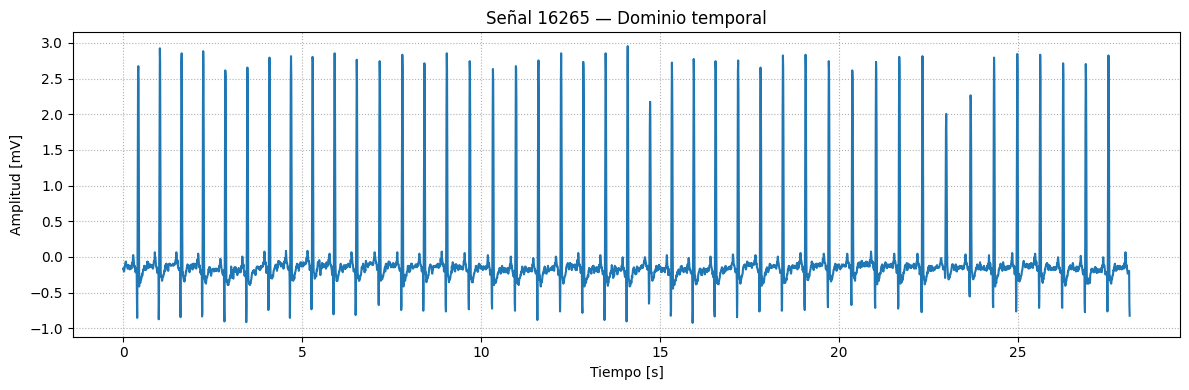

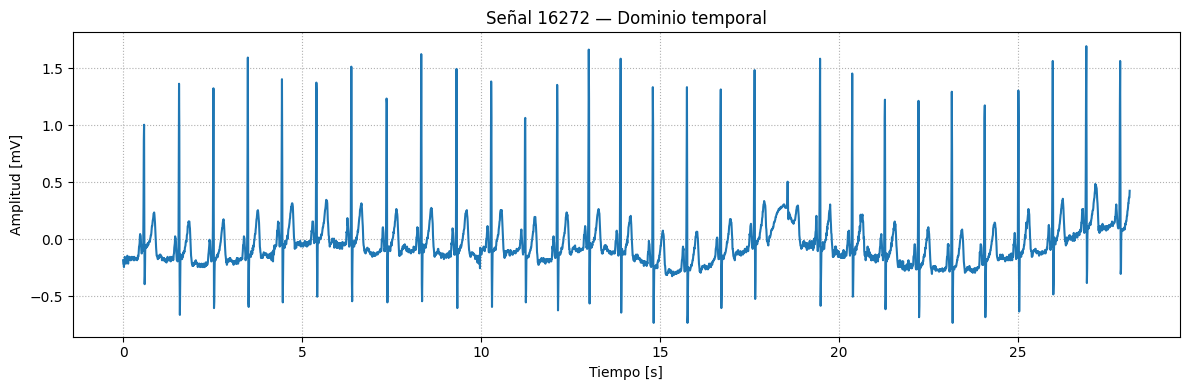

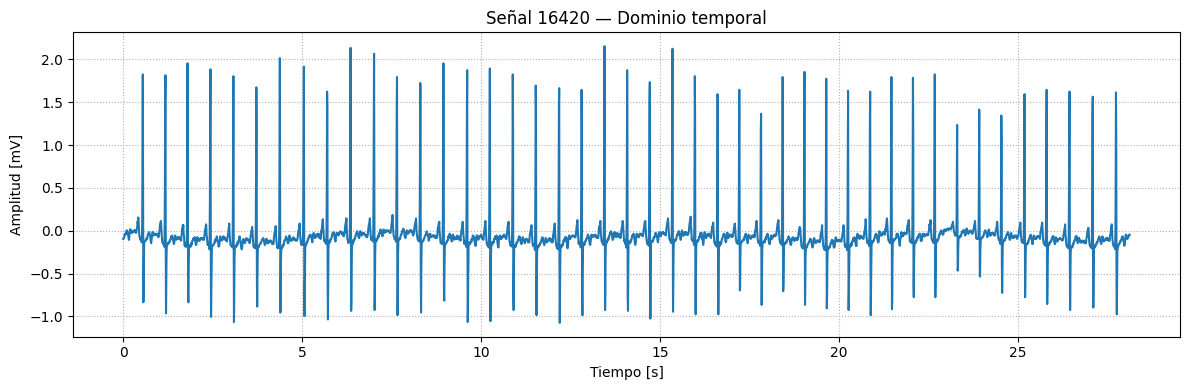

In [ ]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?

   Si, las tres señales presentan una morfología bastante similiar.
2. ¿Cuál presenta mayor variación de amplitud?

   La señal 16265 con una variación aproximada de amplitud desde -1.00 mV hasta 3.00 mV.
3. ¿Se observan patrones periódicos?

   Si, las 3 señales presentan patrones periódicos.
4. ¿Se identifican eventos o cambios particulares?

   Sí. La señal 16272 presenta cambios más notorios en su línea base, especialmente alrededor de 18 s y hacia el final de la señal. En 16265 también aparecen algunos picos de menor amplitud alrededor de 15 s y 23-24 s. La señal 16420 presenta picos de amplitud variada.
5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?

   La amplitud de los picos, duración de la señal, periodicidad, separación entre eventos, variaciones de la línea base y posibles eventos anormales o cambios puntuales.

# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [ ]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [ ]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


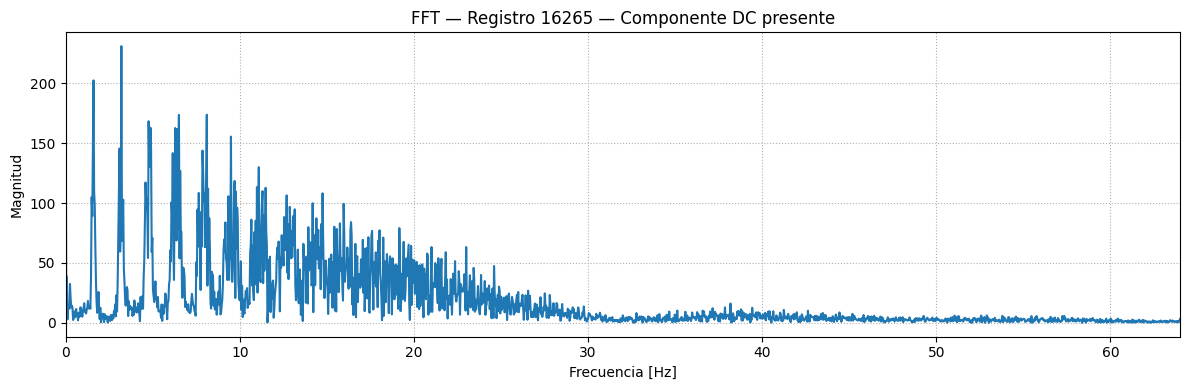

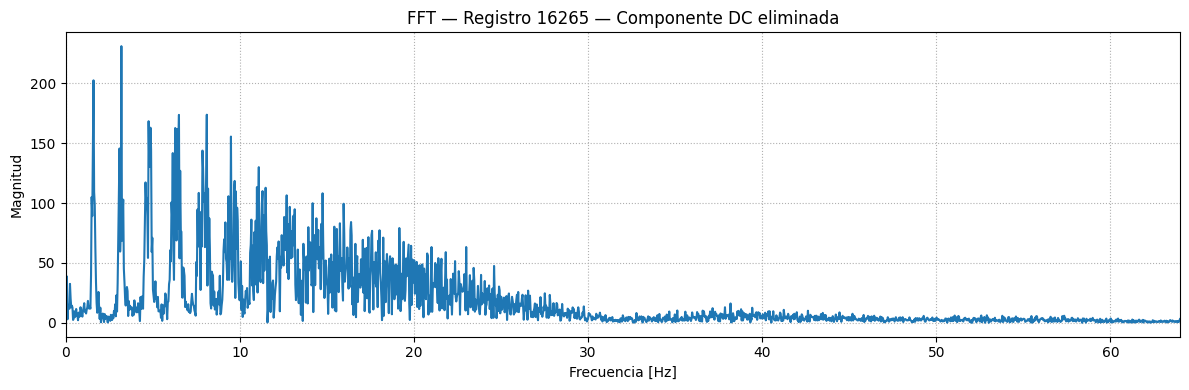

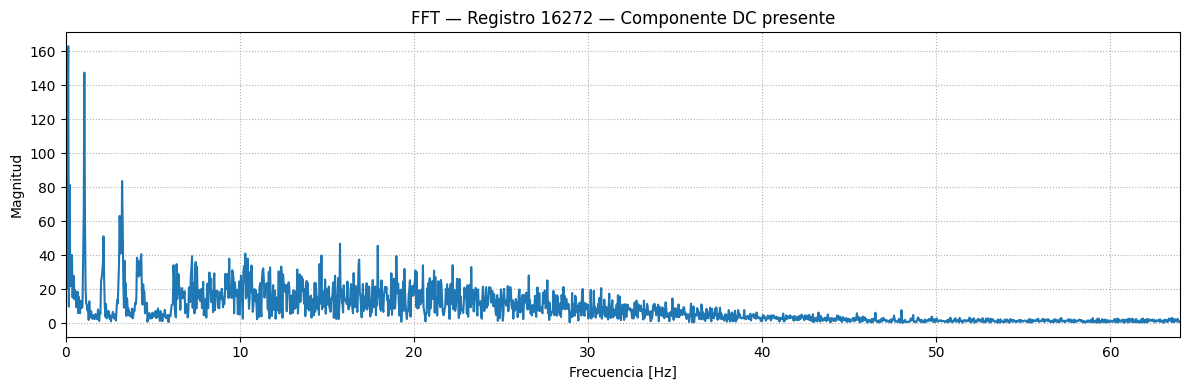

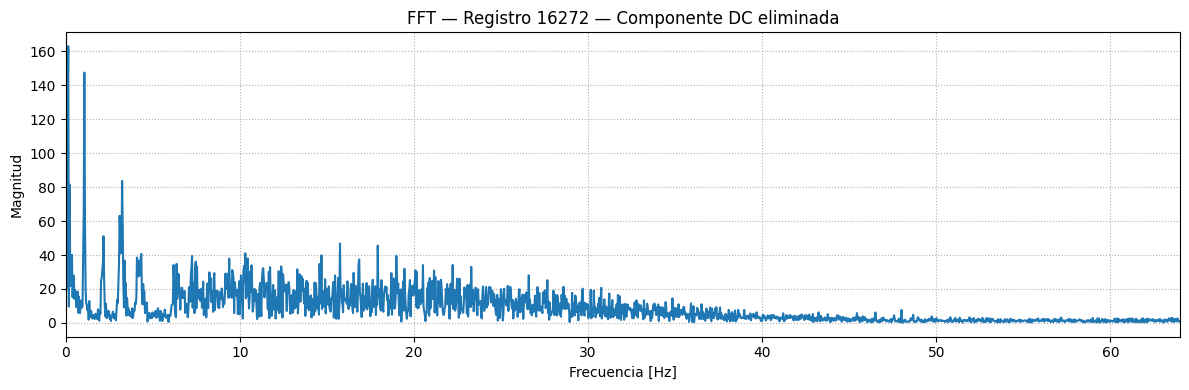

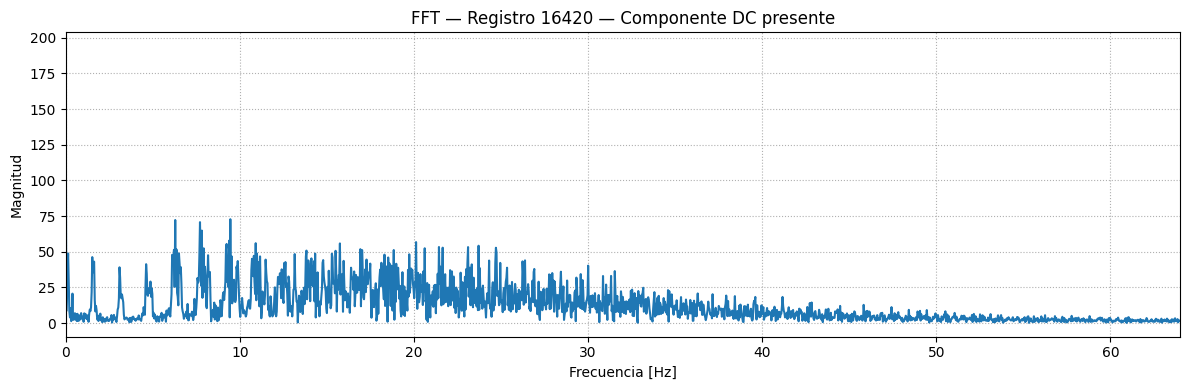

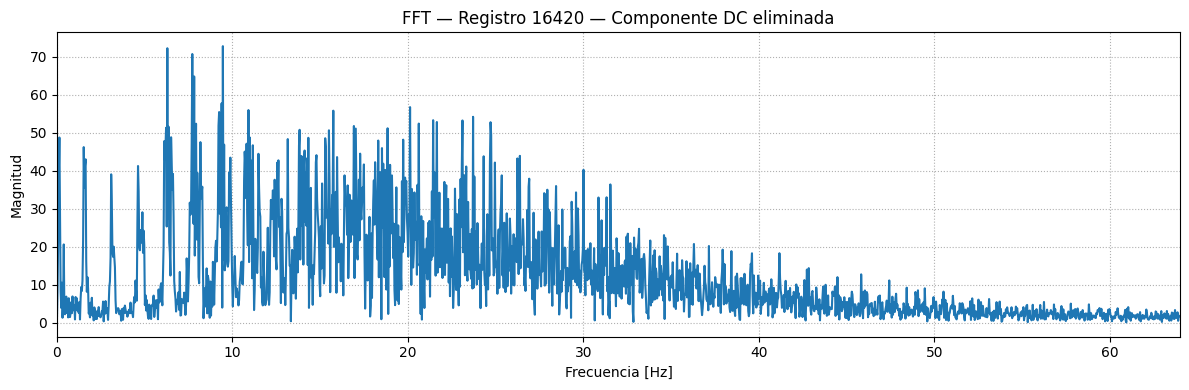

In [ ]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?

   El componente en 0 Hz disminuye considerablemente o desaparece, ya que representa la componente DC asociada al valor medio de la señal.
2. ¿Qué diferencias observa entre los espectros de los tres registros?

   Los tres presentan distribuciones diferentes de magnitud. El registro 16265 presenta picos de mayor magnitud y varias componentes importantes en bajas y medias frecuencias. El 16272 concentra componentes importantes principalmente en frecuencias bajas, mientras que el 16420 presenta un espectro más distribuido, especialmente aproximadamente entre 5 y 35 Hz. En 16420 se observa además claramente el efecto de eliminar la componente DC.
3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?

   En los tres registros, la mayor parte de la energía se concentra aproximadamente por debajo de 30-35 Hz, siendo especialmente importante la zona de bajas frecuencias.
4. ¿Por qué la FFT no conserva directamente la información temporal?

   Porque la FFT transforma la señal del dominio del tiempo al dominio de la frecuencia e indica qué frecuencias están presentes y con qué magnitud.
5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?
   
   Permite identificar fácilmente las frecuencias dominantes, componentes periódicas y posibles componentes de ruido, lo que puede ser difícil de identificar en el dominio del tiempo.


# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [ ]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 3.200 Hz, magnitud = 230.841
Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 163.096
Registro 16420: frecuencia dominante = 9.458 Hz, magnitud = 72.800


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [ ]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [ ]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 32,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 32, ventanas calculadas = 226
16420: nperseg = 256, ventanas calculadas = 30


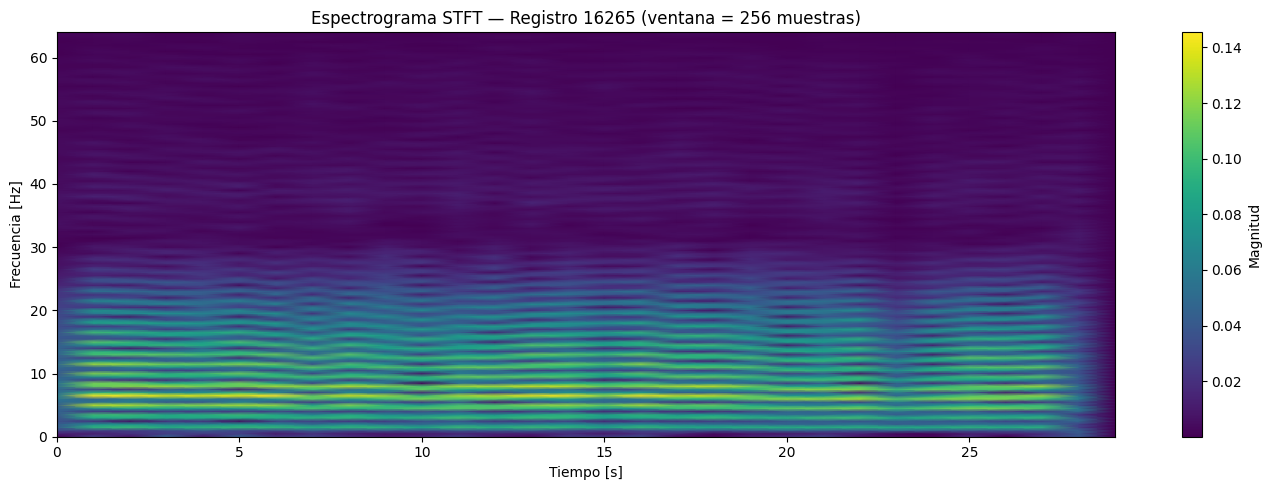

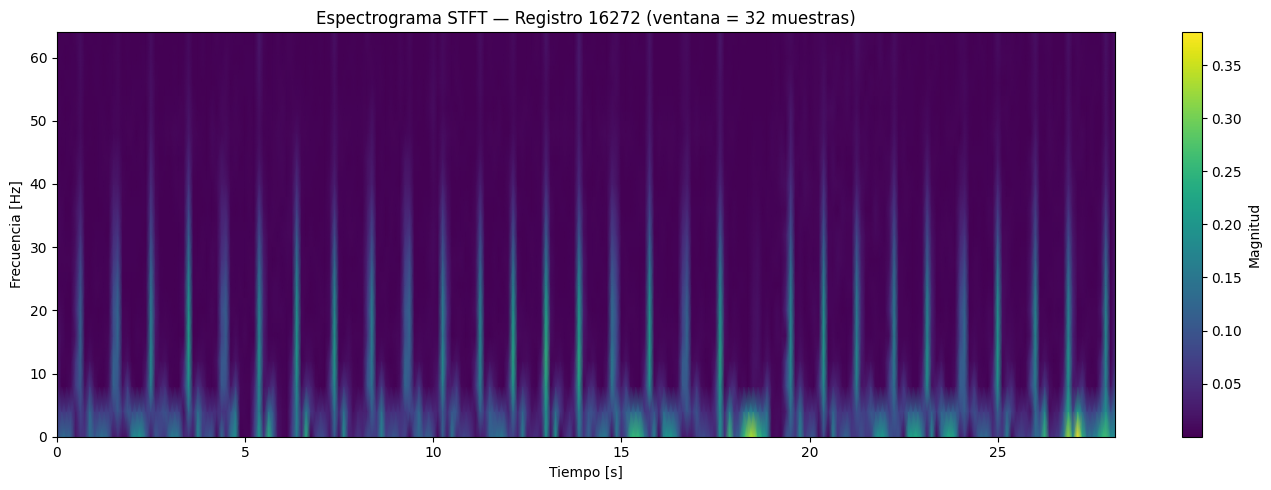

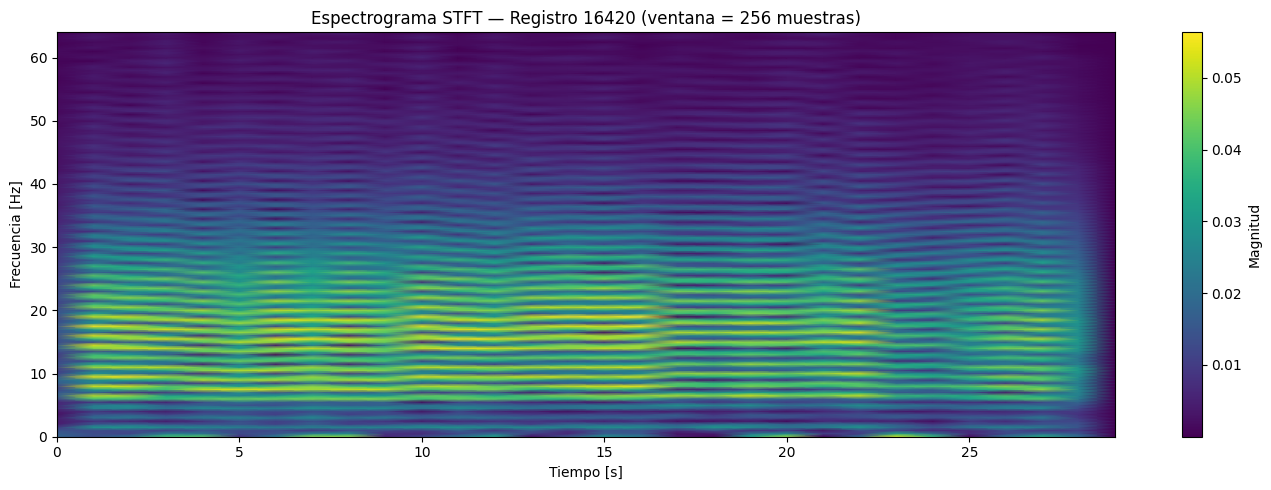

In [ ]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?

   La STFT permite observar qué frecuencias aparecen y en qué momento aparecen, mientras que la FFT solo muestra qué frecuencias están presentes en toda la señal, sin indicar cuándo ocurren.
2. ¿En qué momentos se observan cambios de energía?

   En 16265 la energía es más intensa al inicio y presenta variaciones entre aproximadamente 10-28 s. En 16272 se observan eventos puntuales de alta energía distribuidos en casi todo el registro. En 16420 la energía es más continua, aunque cambia ligeramente alrededor de 20-27 s.
3. ¿Qué diferencias observa entre los tres espectrogramas?

   El registro 16265 concentra mayor energía principalmente por debajo de 25-30 Hz, con bandas horizontales bien definidas.
   El 16272 muestra eventos más breves y localizados en el tiempo, representados por líneas verticales; la energía se concentra principalmente en bajas frecuencias. El 16420 presenta una distribución más amplia y continua de energía, aproximadamente hasta 35-40 Hz, con varias bandas horizontales.
4. ¿Por qué el registro `16272` utiliza una ventana de 32 muestras?

   Porque presenta cambios rápidos y eventos cortos en el tiempo. Una ventana pequeña de 32 muestras mejora la resolución temporal, permitiendo localizar mejor cuándo ocurren esos eventos.
5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?

   Se obtiene una mejor resolución en frecuencia, pero se pierde resolución temporal. Los eventos rápidos podrían aparecer difuminados o mezclados, dificultando identificar el momento exacto en que ocurren.
6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?

   Se mejora la resolución temporal, pero empeora la resolución en frecuencia. Las frecuencias pueden verse menos definidas o más anchas, haciendo más difícil distinguir componentes cercanas entre sí.


# 13. Comparación de los tres registros

Complete la siguiente tabla a partir de los resultados obtenidos.

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo | 128 Hz | 128 Hz | 128 Hz |
| Número de muestras | 3600 | 3600 | 3600 |
| Número de canales | 2 | 2 | 2 |
| Amplitud observada | -1 mV - 3 mV | -0.6 mV - 1.6 mV | -1.1 mV - 2.2 mV |
| Componente DC | -0.0587 mV | -0.0421 mV | -0.0539 mV |
| Frecuencias dominantes | 3.200 Hz | 0.142 Hz | 9.458 Hz |
| Comportamiento STFT | Energía principalmente bajo<br>25-30 Hz, con bandas<br>horizontales definidas | Eventos breves y localizados<br>en el tiempo, con predominio<br>de bajas frecuencias | Energía más continua y<br>distribuida, aproximadamente<br>hasta 35-40 Hz |
| Observaciones | Señal periódica, con picos<br>de mayor amplitud y algunos<br>eventos de menor amplitud | Mayor irregularidad temporal<br>y variaciones en la línea base | Señal más uniforme y regular,<br>con contenido frecuencial<br>más distribuido |

### Discusión

Explique:

- **qué registro presenta mayor variabilidad;**
El registro 16272 presenta la mayor variabilidad global debido a los desplazamientos significativos de su línea base (drift) y a la presencia de transitorios o artefactos de corta duración.

- **qué diferencias aparecen en el dominio temporal;**
Mientras que 16265 presenta picos QRS bien definidos y de alta amplitud, 16272 muestra fluctuaciones marcadas en el nivel medio, y 16420 exhibe una amplitud más regular y uniforme con variaciones moderadas entre ciclos.

- **qué diferencias aparecen en el dominio frecuencial;**
16265 concentra picos de gran amplitud en bajas y medias frecuencias (alrededor de 3.2 Hz); 16272 acumula casi toda su energía en una frecuencia muy baja (0.142 Hz), reflejando la deriva de la línea base; 16420 distribuye su energía en un ancho de banda mayor (entre 5 Hz y 35 Hz).

- **qué información adicional aporta la STFT;**
La FFT promedia el contenido frecuencial de toda la señal, perdiendo la coordenada del tiempo. La STFT resuelve esto al mapear el contenido frecuencial en función del tiempo, permitiendo localizar en qué segundo exacto ocurren los cambios bruscos de energía o ruidos transitorios.

- **cómo influye el tamaño de ventana.**
Existe un compromiso (*trade-off*) regido por el principio de incertidumbre: una ventana grande ($n_{perseg}$ alto) mejora la resolución en frecuencia pero pierde resolución temporal; una ventana pequeña ($n_{perseg}$ bajo) precisa el instante exacto de un evento pero ensancha las componentes en el espectro.

# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal

Modifique:

```python
SAMPFROM = 0
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

### Analice

**1. ¿La morfología cambia?**  
No, los tres registros conservan el patron general, aunque cambian la amplitud de algunos eventos y la línea base. El registro 16272 sigue siendo el más irregular, mientras que 16265 y 16420 mantienen una morfología más estable.

**2. ¿El espectro cambia?**  
Sí. Se observan cambios en la magnitud de las componentes y también en la frecuencia dominante. En el segmento original las frecuencias dominantes eran aproximadamente 3.200 Hz, 0.142 Hz y 9.458 Hz, mientras que en el segmento posterior pasan a 1.564 Hz, 1.031 Hz y 6.400 Hz para 16265, 16272 y 16420, respectivamente.

**3. ¿La STFT muestra nuevos eventos?**  
Sí. La STFT del segmento posterior muestra variaciones de energía diferentes a las del segmento original. En 16272 siguen apareciendo eventos breves y localizados en el tiempo, mientras que en 16265 y 16420 la energía se distribuye de forma más continua, principalmente en bajas y medias frecuencias.

**4. ¿Qué diferencias encuentra respecto al segmento original?**  
El segmento posterior mantiene las características generales de cada registro, pero presenta cambios en amplitud, distribución espectral y frecuencia dominante. 16265 sigue mostrando energía concentrada principalmente por debajo de 30 Hz, 16272 mantiene eventos temporales bien localizados y 16420 conserva una distribución espectral más amplia.

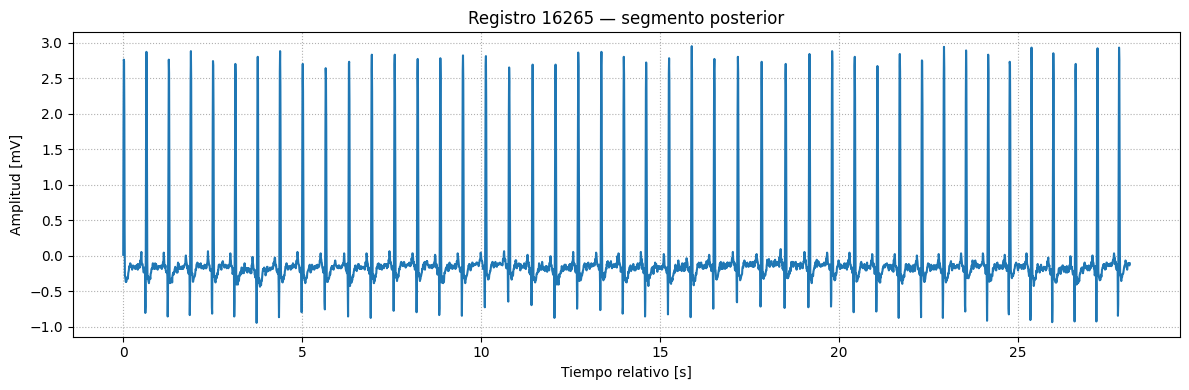

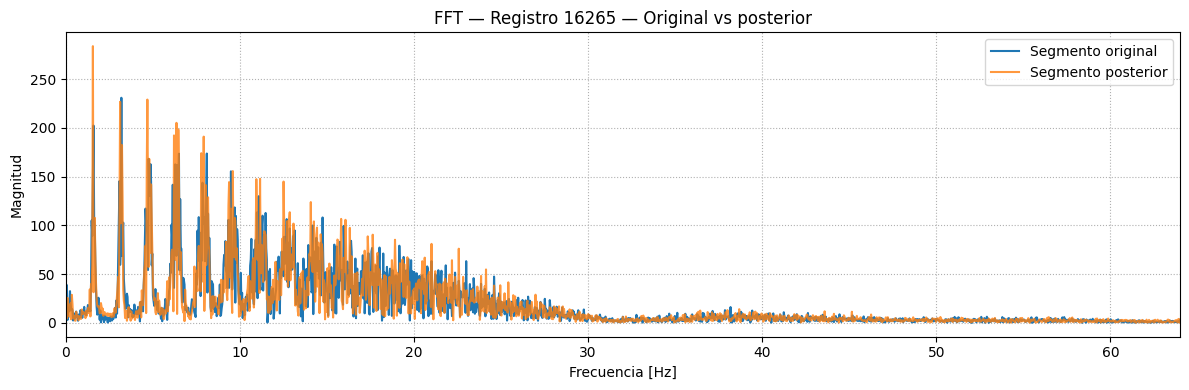

Registro 16265: frecuencia dominante posterior = 1.564 Hz


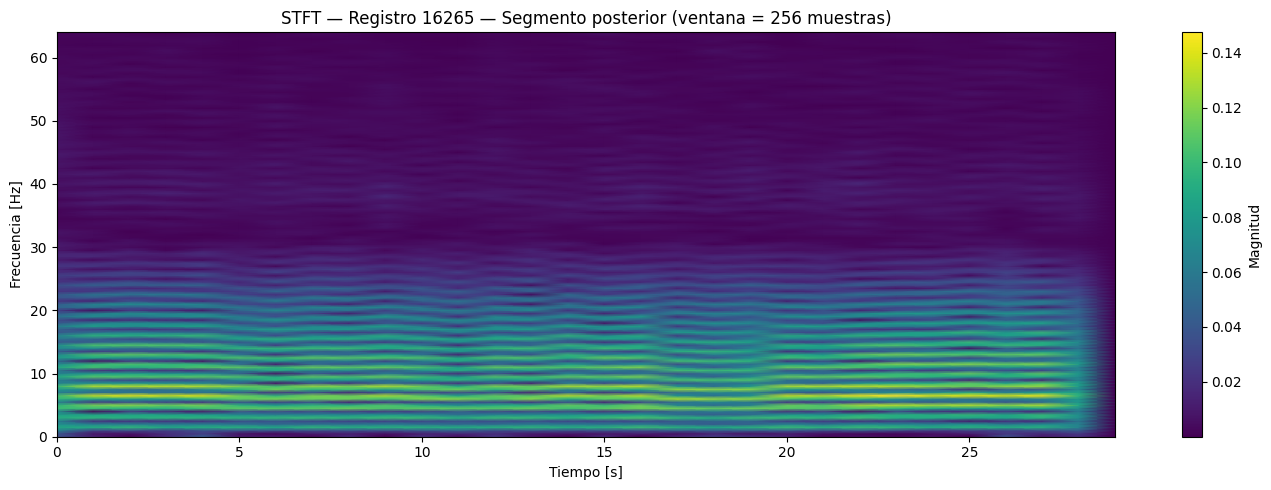

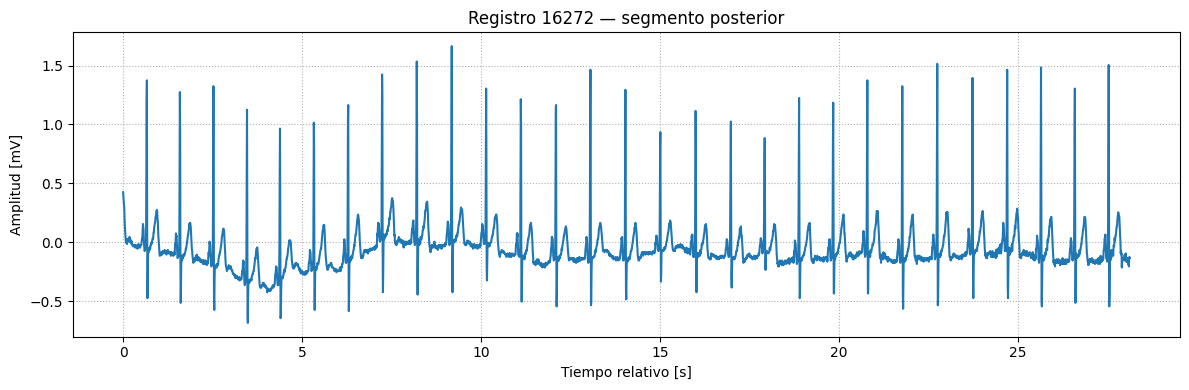

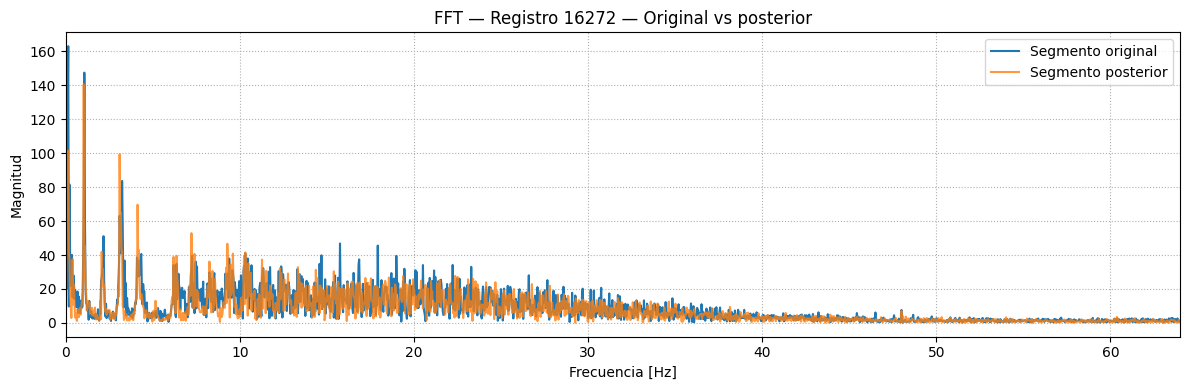

Registro 16272: frecuencia dominante posterior = 1.031 Hz


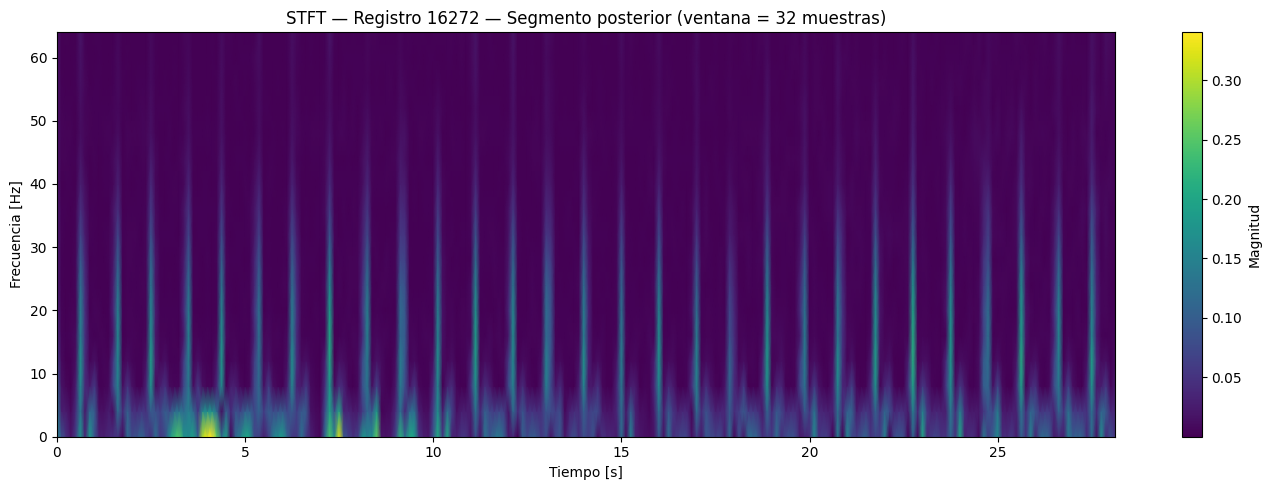

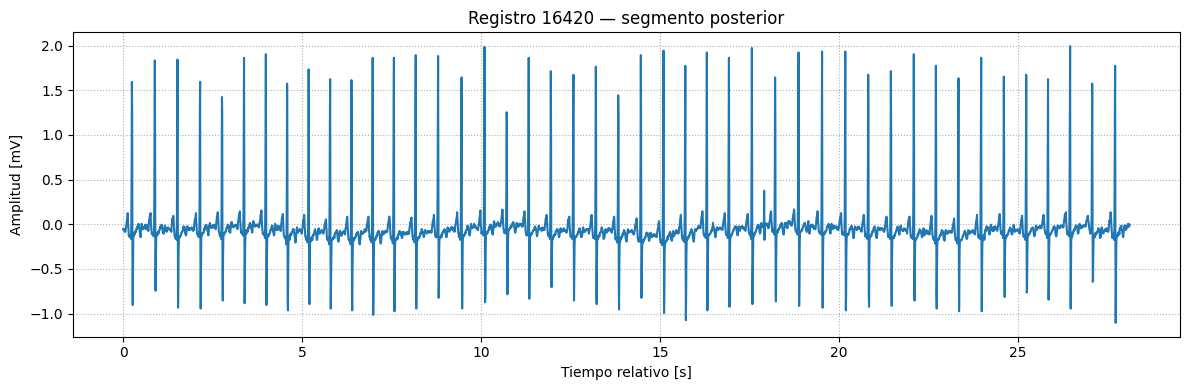

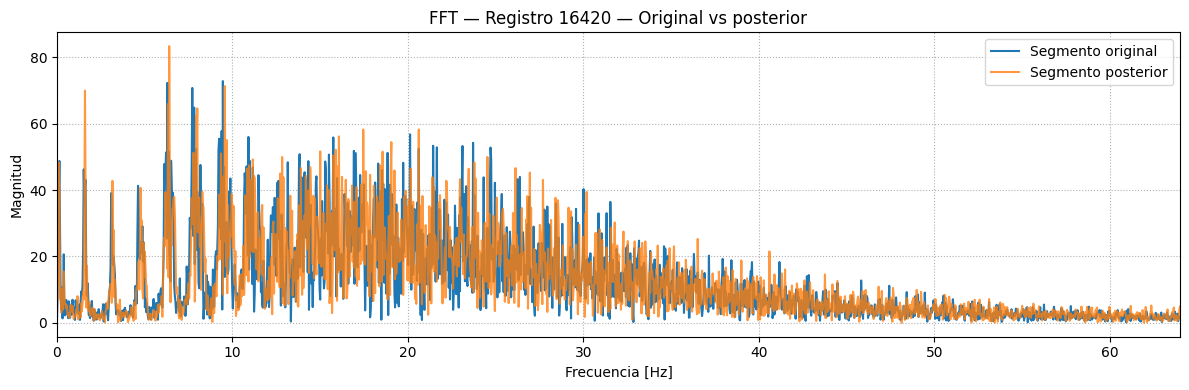

Registro 16420: frecuencia dominante posterior = 6.400 Hz


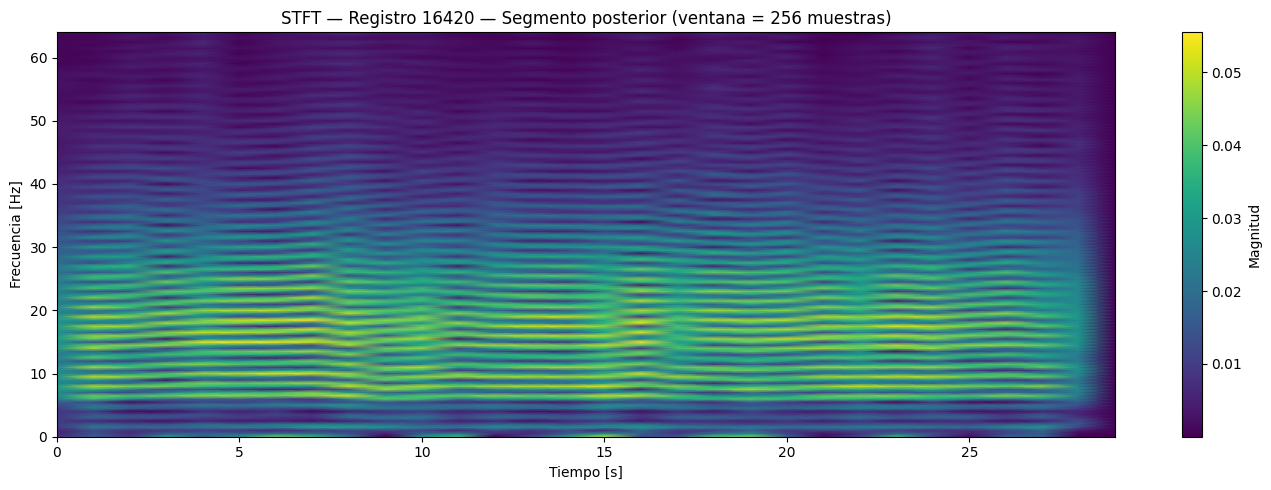

In [ ]:
SAMPFROM_POST = 3600

signals_post = {}
fft_data_post = {}
stft_data_post = {}

for record_name in RECORDS:

    # Cargar segmento posterior
    record_post = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM_POST,
        sampto=SAMPFROM_POST + SAMPLING_POINTS
    )

    fs = record_post.fs
    x = record_post.p_signal[:, CHANNEL]

    signals_post[record_name] = x

    # ========================================
    # 1. DOMINIO TEMPORAL
    # ========================================

    t = np.arange(len(x)) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(
        f"Registro {record_name} — segmento posterior"
    )
    plt.xlabel("Tiempo relativo [s]")
    plt.ylabel("Amplitud [mV]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


    # ========================================
    # 2. FFT DEL SEGMENTO POSTERIOR
    # ========================================

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data_post[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    # Comparación FFT original vs posterior
    plt.figure(figsize=(12, 4))

    plt.plot(
        fft_data[record_name]["frequencies"],
        fft_data[record_name]["magnitude_ac"],
        label="Segmento original"
    )

    plt.plot(
        frequencies,
        magnitude_ac,
        label="Segmento posterior",
        alpha=0.8
    )

    plt.title(
        f"FFT — Registro {record_name} — Original vs posterior"
    )
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, frequencies[-1])
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


    # Frecuencia dominante del segmento posterior
    idx = np.argmax(magnitude_ac[1:]) + 1

    dominant_frequency_post = frequencies[idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante posterior = "
        f"{dominant_frequency_post:.3f} Hz"
    )


    # ========================================
    # 3. STFT DEL SEGMENTO POSTERIOR
    # ========================================

    nperseg = WINDOWS[record_name]

    f_post, t_post, zxx_post = calculate_stft(
        x_dc_removed,
        fs,
        nperseg=nperseg
    )

    stft_data_post[record_name] = {
        "f": f_post,
        "t": t_post,
        "zxx": zxx_post
    }

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t_post,
        f_post,
        np.abs(zxx_post),
        shading="gouraud"
    )

    plt.title(
        f"STFT — Registro {record_name} — Segmento posterior "
        f"(ventana = {nperseg} muestras)"
    )

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()

## Ejercicio 2.2 — Cambiar el tamaño de ventana

Para el registro `16272`, compare:

```python
nperseg = 32
```

con:

```python
nperseg = 128
```

y:

```python
nperseg = 256
```

### Responda

**1. ¿Cuál permite observar mejor los eventos temporales?**  
La ventana de 32 muestras, porque los eventos aparecen como líneas verticales más estrechas y mejor localizadas en el tiempo. Se puede distinguir con mayor claridad cuándo ocurre cada evento.

**2. ¿Cuál proporciona mayor detalle en frecuencia?**  
La ventana de 256 muestras, porque las bandas horizontales están más definidas y se distinguen mejor las componentes frecuenciales.

**3. ¿Cuál considera más apropiada para este registro? Justifique.**  
Para el registro 16272, la ventana de 32 muestras es la más apropiada si el objetivo es identificar eventos rápidos y localizados, porque ofrece mejor resolución temporal. La ventana de 128 muestras representa un equilibrio entre resolución temporal y frecuencial, mientras que la de 256 muestras mejora el detalle en frecuencia pero hace que los eventos aparezcan más difuminados en el tiempo.

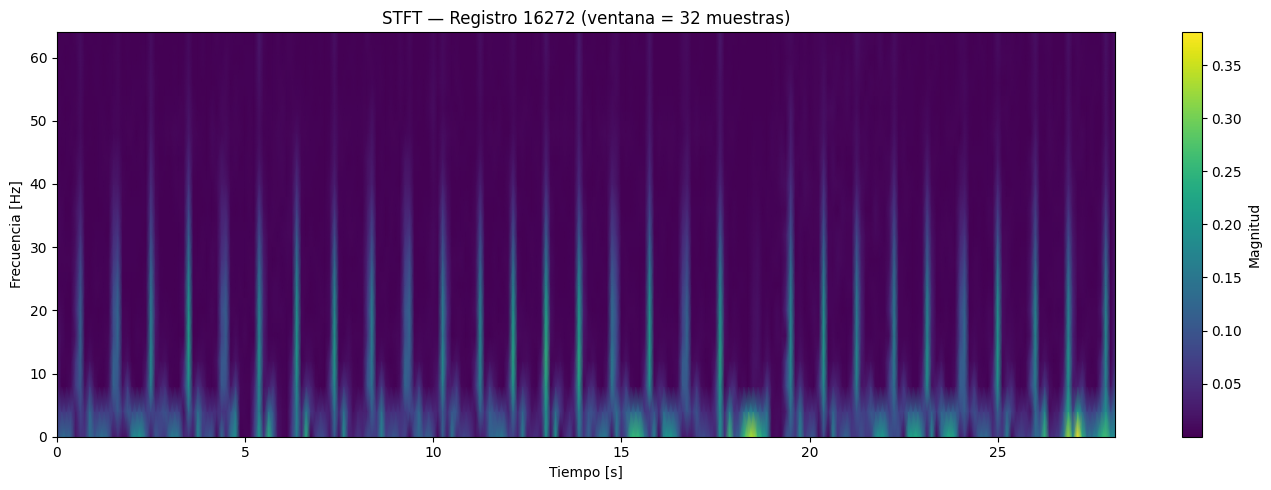

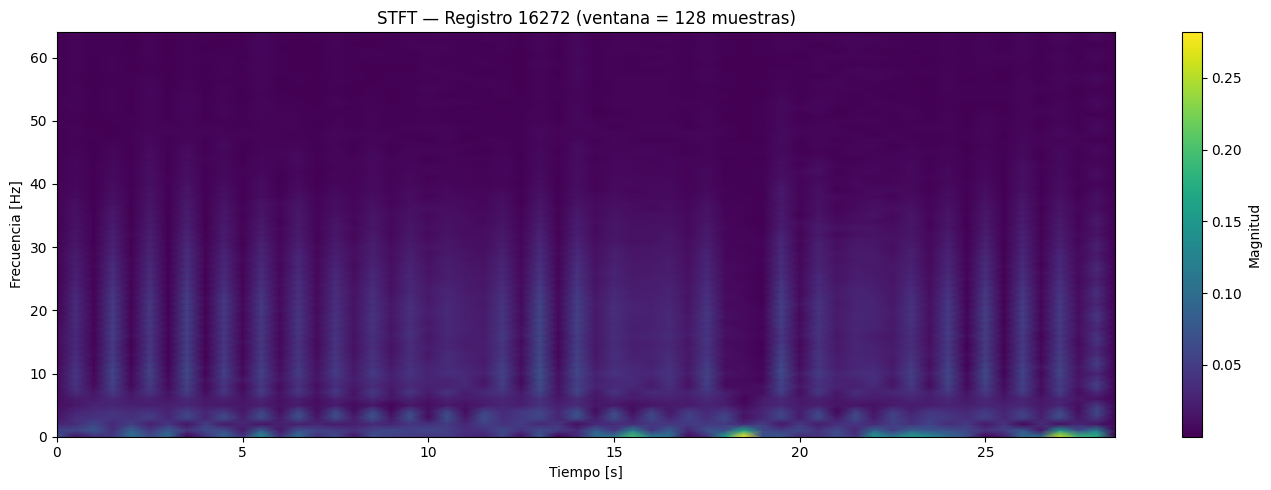

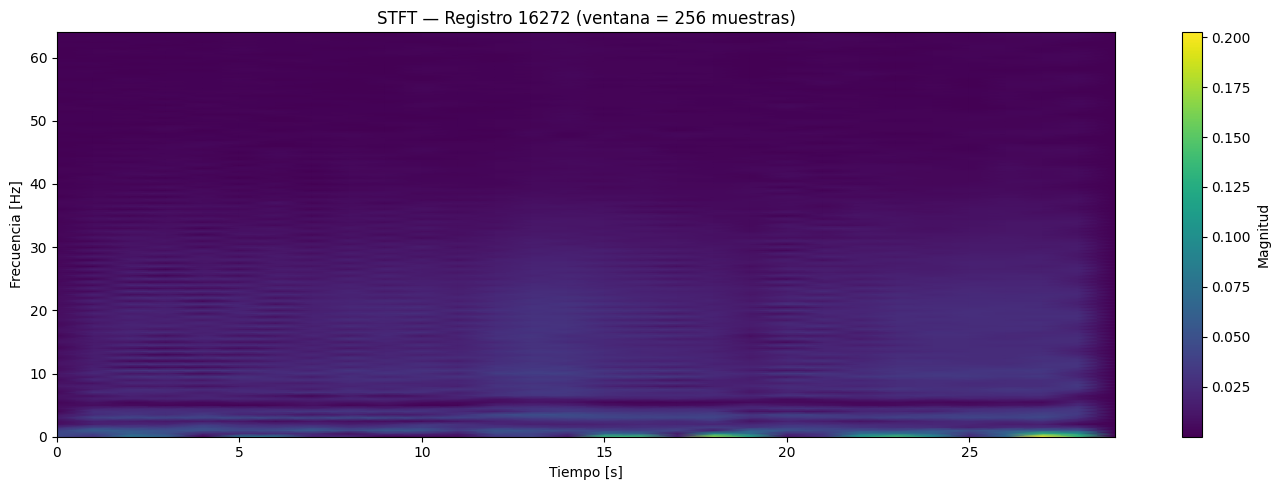

In [ ]:
record_name = "16272"

x = fft_data[record_name]["signal_ac"]
fs = sampling_rates[record_name]

window_sizes = [32, 128, 256]

for nperseg in window_sizes:

    f, t_stft, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t_stft,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"STFT — Registro {record_name} "
        f"(ventana = {nperseg} muestras)"
    )

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")

    plt.colorbar(label="Magnitud")

    plt.ylim(0, 64)

    plt.tight_layout()
    plt.show()

### Ejercicio 2.3 — Comparación FFT vs. STFT

**Explique con sus propias palabras:**  

> ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento, mientras que una STFT puede localizarlo temporalmente?

La FFT global calcula el contenido frecuencial integrando la señal completa a lo largo de todo el tiempo de registro. Por esta razón, indica qué frecuencias están presentes y con qué magnitud, pero pierde por completo la información de cuándo aparecieron.

Por el contrario, la STFT divide la señal en pequeños segmentos de tiempo utilizando una ventana deslizante y calcula una FFT para cada uno. Esto genera una representación bidimensional (tiempo-frecuencia) que permite ubicar con exactitud el instante de tiempo en el que aparece, cambia o desaparece cada componente de frecuencia.


# 15. Preguntas conceptuales

Responda con sus propias palabras.

1. ¿Qué es PhysioNet?
   
   Es una plataforma y repositorio de acceso abierto respaldado por el MIT que proporciona acceso a bases de datos de señales fisiológicas digitalizadas (como ECG, EEG, etc.) y herramientas de software libre para la investigación biomédica.

2. ¿Qué información proporciona `record.p_signal`?
   
   Es un arreglo bidimensional de NumPy que contiene las muestras procesadas de la señal biomédica expresadas en unidades físicas reales (por ejemplo, milivoltios, mV). La estructura es `[muestras, canales]`.

3. ¿Qué representa la frecuencia de muestreo `fs`?
   
   Representa la cantidad de muestras o lecturas discretas tomadas de la señal analógica por cada segundo de tiempo. Su unidad de medida es el Hertz (Hz).

4. ¿Qué representa la componente DC de una señal?
   
   Representa el valor promedio o valor medio de la señal a lo largo del tiempo. En el espectro de frecuencias corresponde a la amplitud presente en $0\text{ Hz}$.

5. ¿Por qué se resta la media antes de analizar el espectro AC?
   
   Porque la componente DC suele tener una magnitud muy grande en comparación con las variaciones de la señal. Si no se resta, el pico en $0\text{ Hz}$ distorsiona la escala vertical del gráfico e impide visualizar adecuadamente las componentes frecuenciales de interés.

6. ¿Qué información proporciona la FFT?
   
   Proporciona el espectro de magnitudes de la señal, indicando qué componentes frecuenciales están presentes y cuánta energía tiene cada una en todo el registro, pero sin indicar en qué momento ocurren.

7. ¿Qué información adicional proporciona la STFT?
   
   Proporciona una representación tiempo-frecuencia que permite observar cómo evoluciona el contenido frecuencial de la señal a lo largo del tiempo, indicando qué frecuencias aparecen y en qué instantes exactos ocurren.

8. ¿Qué relación existe entre `fs`, número de muestras y duración?
   
   La relación matemática es:
$$\text{Duración } (t) = \frac{\text{Número de muestras } (N)}{f_s}$$

9. ¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?
   
   Mejora la resolución en frecuencia (permite distinguir componentes de frecuencia muy cercanas), pero empeora la resolución temporal (se difuminan los instantes en que ocurren eventos rápidos).

10. ¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?

    Porque la representación temporal $x(t)$ superpone todas las componentes en una sola gráfica. Fenómenos como interferencias de la red eléctrica ($50/60\text{ Hz}$), ruidos de baja frecuencia o variaciones espectrales específicas son difíciles de identificar a simple vista en el tiempo y requieren del dominio frecuencial para su correcto análisis y filtrado.

# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.
2. Frecuencia de muestreo.
3. Canal analizado.
4. Gráfica temporal.
5. FFT con DC.
6. FFT sin DC.
7. Espectrograma STFT.
8. Comparación de resultados.
9. Respuestas a las preguntas de análisis.
10. Conclusiones.


### Desarrollo del Entregable

1. Registro seleccionado

   Se seleccionó el registro `16265`



In [ ]:
SELECTED_RECORD = "16265"

print(f"Registro seleccionado: {SELECTED_RECORD}")

Registro seleccionado: 16265


2. Frecuencia de muestreo

   La frecuencia de muestreo del registro es: 128 Hz. Esto significa que se registran 128 muestras por segundo.



In [ ]:
record = records_data[SELECTED_RECORD]

fs = record.fs

print(f"Frecuencia de muestreo: {fs} Hz")

Frecuencia de muestreo: 128 Hz


3. Canal analizado

   Se analizó el canal `0`, correspondiente a la señal `ECG1`, expresada en milivoltios (mV).



In [ ]:
print(f"Canal analizado: {CHANNEL}")
print(f"Nombre del canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")

Canal analizado: 0
Nombre del canal: ECG1
Unidad: mV


4. Grafica temporal

   El segmento analizado contiene 3600 muestras. Por lo tanto, su duración es: 3600/128 = 28.125 Hz

   En la gráfica temporal se observan picos repetitivos y un comportamiento aproximadamente periódico. La amplitud se encuentra aproximadamente entre -1 mV - 3 mV

   También se observan algunos eventos en los que la amplitud de los picos disminuye respecto al comportamiento predominante.



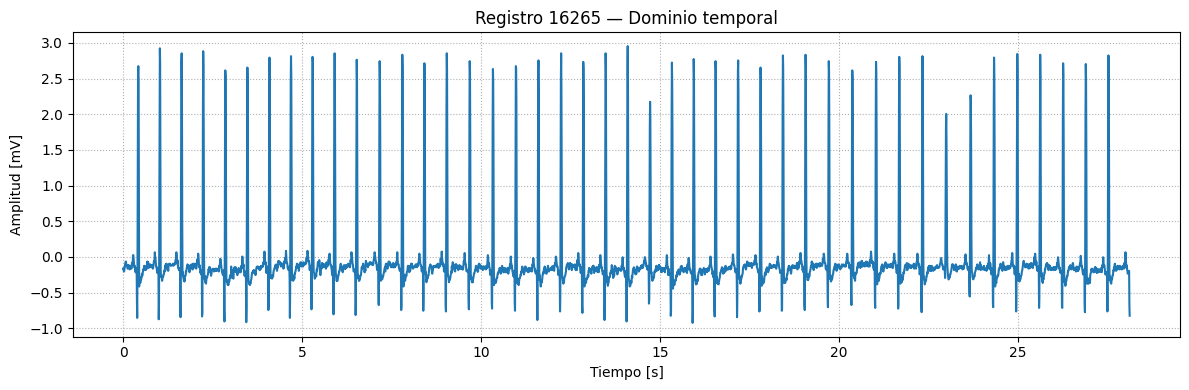

In [ ]:
x = signals[SELECTED_RECORD]
t = times[SELECTED_RECORD]

plt.figure(figsize=(12, 4))

plt.plot(t, x)

plt.title(f"Registro {SELECTED_RECORD} — Dominio temporal")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

5. FFT con componente DC

   Al calcular la FFT de la señal original se obtiene el contenido frecuencial completo, incluyendo la componente DC asociada al valor medio de la señal.

   Para el registro `16265`, el valor medio obtenido fue aproximadamente: DC=-0.0587 mV

   La mayor parte del contenido espectral se concentra en las frecuencias bajas y medias, principalmente por debajo de aproximadamente 30 Hz.



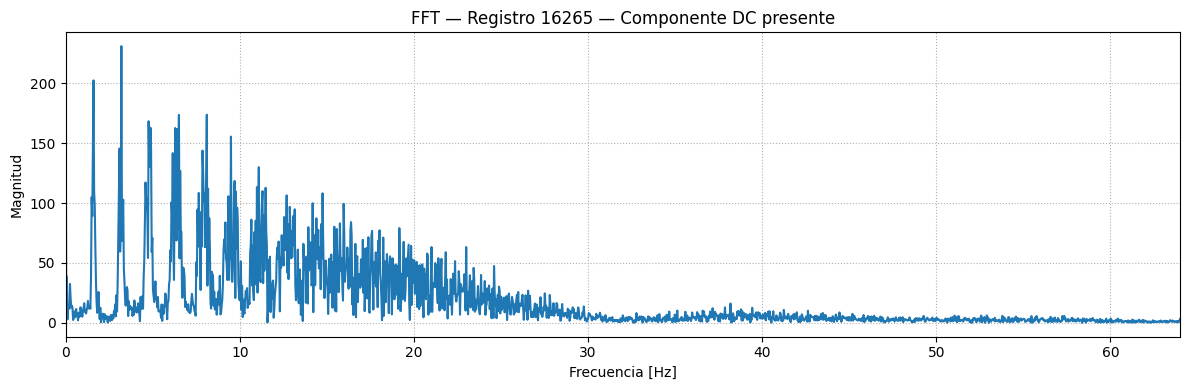

In [ ]:
frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
    x,
    fs
)

plt.figure(figsize=(12, 4))

plt.plot(
    frequencies,
    magnitude_original
)

plt.title(
    f"FFT — Registro {SELECTED_RECORD} — Componente DC presente"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")

plt.xlim(0, frequencies[-1])

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

6. FFT sin componente DC

   Para eliminar la componente DC se resta el valor medio de la señal. Después de eliminar la media, la componente ubicada en 0 Hz disminuye considerablemente, lo que permite observar mejor las componentes variables de la señal. La frecuencia dominante calculada para el segmento original fue 3.2 Hz. Este valor representa la frecuencia con mayor magnitud dentro del espectro analizado.


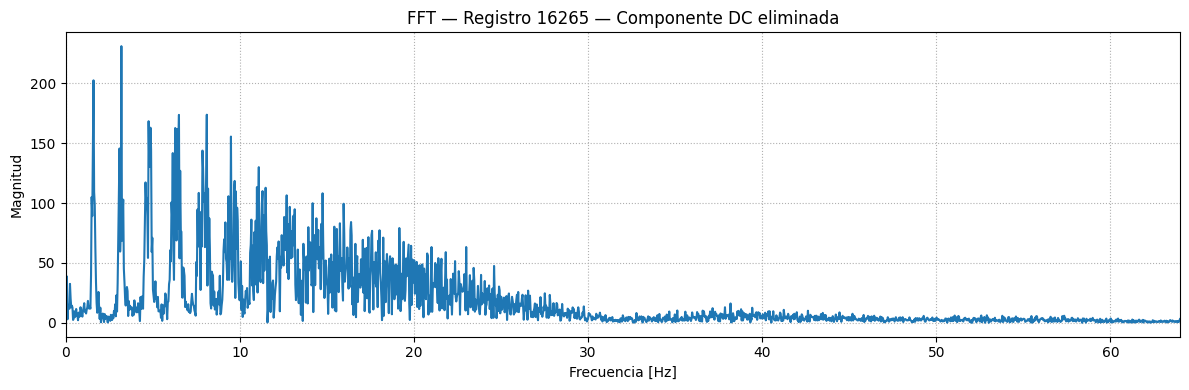

Frecuencia dominante: 3.200 Hz
Magnitud dominante: 230.841


In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(
    frequencies,
    magnitude_ac
)

plt.title(
    f"FFT — Registro {SELECTED_RECORD} — Componente DC eliminada"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")

plt.xlim(0, frequencies[-1])

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

idx = np.argmax(magnitude_ac[1:]) + 1

dominant_frequency = frequencies[idx]
dominant_magnitude = magnitude_ac[idx]

print(
    f"Frecuencia dominante: "
    f"{dominant_frequency:.3f} Hz"
)

print(
    f"Magnitud dominante: "
    f"{dominant_magnitude:.3f}"
)


7. Espectrograma STFT

   Para el registro `16265` se utilizó una ventana de 256 muestras

   El espectrograma muestra bandas horizontales relativamente definidas y una mayor concentración de energía aproximadamente por debajo de 25-30 Hz.

   También se observa que la intensidad de algunas componentes cambia ligeramente a lo largo del tiempo, algo que no puede identificarse directamente con una FFT global.



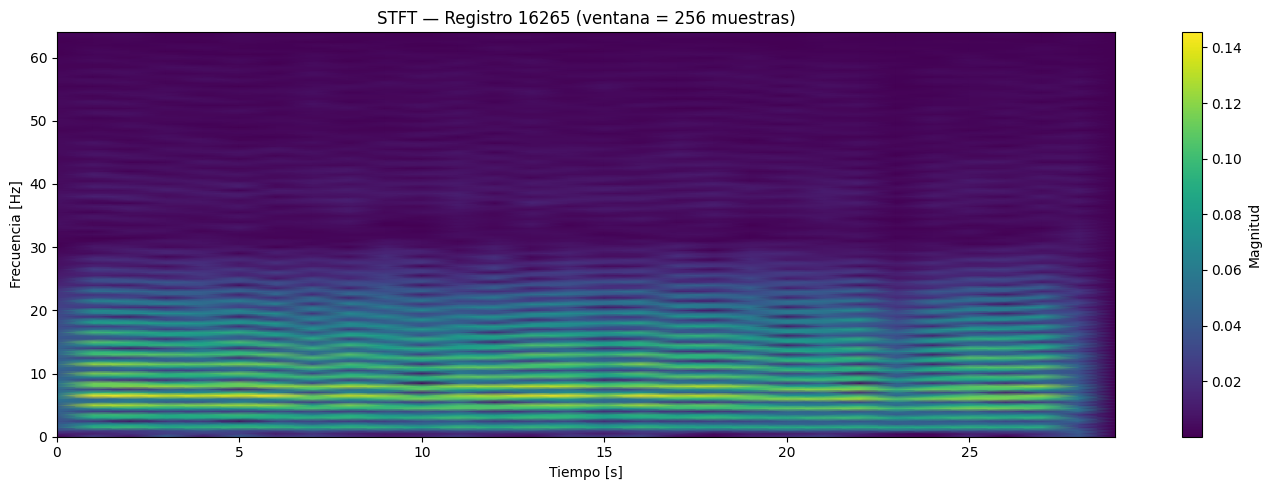

In [ ]:
nperseg = WINDOWS[SELECTED_RECORD]

f_stft, t_stft, zxx = calculate_stft(
    x_dc_removed,
    fs,
    nperseg=nperseg
)

plt.figure(figsize=(14, 5))

plt.pcolormesh(
    t_stft,
    f_stft,
    np.abs(zxx),
    shading="gouraud"
)

plt.title(
    f"STFT — Registro {SELECTED_RECORD} "
    f"(ventana = {nperseg} muestras)"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")

plt.colorbar(label="Magnitud")

plt.tight_layout()
plt.show()

8. Comparación de resultados

   Las tres representaciones proporcionan información complementaria:

- **Dominio temporal:** permite observar la amplitud, periodicidad, forma de la señal y eventos particulares.
- **FFT:** permite identificar las componentes frecuenciales presentes en todo el segmento y determinar la frecuencia dominante.
- **STFT:** permite observar cómo cambia el contenido frecuencial a lo largo del tiempo y localizar temporalmente los cambios de energía.

   Por ello, la FFT proporciona información global de frecuencia, mientras que la STFT permite relacionar las frecuencias con el momento en el que ocurren.

9. Respuestas a las preguntas de análisis

   **¿Se observan patrones periódicos?**  
   Sí. En la señal temporal se observan picos repetitivos distribuidos de manera aproximadamente periódica.

   **¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?**  
   La mayor parte de la energía se concentra principalmente por debajo de 25-30 Hz.

   **¿Qué ocurre con la componente DC al eliminar la media?**  
   La componente en 0 Hz disminuye considerablemente porque se elimina el valor medio de la señal.

   **¿Qué información adicional proporciona la STFT?**  
   Permite determinar en qué momentos cambian las componentes frecuenciales y la energía de la señal.

   **¿Por qué no es suficiente analizar solamente la señal en el tiempo?**  
   Porque la gráfica temporal permite observar la forma de la señal, pero no permite identificar directamente las frecuencias que la componen. Para ello se requiere complementar el análisis con FFT y STFT.

10. Conclusiones

    El registro `16265` fue analizado en los dominios temporal, frecuencial y tiempo-frecuencia. En el dominio temporal se observaron picos repetitivos y una amplitud aproximada entre -1 mV y 3 mV. Mediante la FFT se identificó una frecuencia dominante cercana a 3.200 Hz y se observó que la mayor parte del contenido frecuencial se concentra en bajas y medias frecuencias. Al eliminar la componente DC se redujo la contribución asociada al valor medio de la señal. Finalmente, la STFT permitió visualizar cómo cambia la energía de las componentes frecuenciales a lo largo del tiempo. Por ello, las tres representaciones proporcionan información complementaria para analizar la señal biomédica.

# 17. Conclusiones esperadas

Al finalizar este ejercicio, el estudiante debe comprender que una señal biomédica puede estudiarse desde tres perspectivas complementarias:

```text
                    SEÑAL BIOMÉDICA
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          TIEMPO       FRECUENCIA    TIEMPO-FRECUENCIA
             │             │             │
           x(t)           FFT           STFT
             │             │             │
             └─────────────┼─────────────┘
                           ↓
                  INTERPRETACIÓN
                     DE LA SEÑAL
```

La representación temporal permite observar la evolución de la amplitud; la FFT permite estudiar el contenido frecuencial global; y la STFT permite analizar cómo cambia dicho contenido con el tiempo.


# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
